# Assignment II: MLP and Backpropagation

Name: Sumira Makaju

ID: 032317-22

Date: April 12, 2026

Dataset: Adult Census Income

## Objective

1. To implement a Multilayer Perceptron (MLP) using PyTorch
2. To understand forward propagation and backpropagation
3. To train the model using different learning rates
4. To analyze convergence behavior and performance
5. To evaluate model using accuracy and loss metrics

## Theoretical Background

**Multilayer Perceptron (MLP)**

A Multilayer Perceptron (MLP) is a class of feedforward artificial neural networks composed of multiple layers of neurons. Unlike simple linear models, MLPs use nonlinear activation functions, enabling them to learn complex patterns and relationships in data.

An MLP typically consists of:

1. **Input Layer**  
   Receives feature vectors from the dataset and passes them to the network.

2. **Hidden Layers**  
   Perform nonlinear transformations using weights, biases, and activation functions.

3. **Output Layer**  
   Produces the final prediction (e.g., probability in binary classification).

Each neuron computes a weighted sum of inputs followed by an activation function:

$$z = w^T x + b$$

$$a = f(z)$$

**Forward Propagation**

Forward propagation is the process of passing input data through the network layer by layer to compute the final output.

**Activation Functions**

Activation functions introduce **non-linearity**, allowing the network to model complex relationships.

1. ReLU (Rectified Linear Unit)
$$f(x) = \max(0, x)$$

2. Sigmoid
$$\sigma(x) = \frac{1}{1 + e^{-x}}$$

**Loss Function**

The loss function measures how far the predicted values are from the actual labels.
$$L = -\frac{1}{N} \sum (y \log(\hat{y}) + (1-y)\log(1-\hat{y}))$$

Where:  
$( y ) = true label  $
$( \hat{y} ) = predicted probability  $

**Backpropagation**

Backpropagation is the algorithm used to compute gradients of the loss function with respect to model parameters. It applies the chain rule of calculus to propagate errors backward through the network.

$\frac{\partial L}{\partial w} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial w}$


**Learning Rate and Convergence**

The learning rate controls how much the weights are updated during training:

1.  **High learning rate**: Faster learning but may overshoot minimum  
2.  **Low learning rate**: More stable but slower convergence  
3.  **Optimal learning rate**: Balanced and smooth convergence  

In [1]:
import pandas as pd

df = pd.read_csv("adultcensusincome.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Dataset Description

**Source**: UCI Machine Learning Repository (via Kaggle)

**no. of samples**: 48,000+

**no. of features**: 14 input features + 1 target

**Target Variable**: Income (>50K)

**Train/Test Split**: 80% training data and 20% testing data  

In [2]:
import numpy as np
# replace the missing values
df.replace("?", np.nan, inplace=True)

# removing missing rows
df.dropna(inplace=True)

In [3]:
df = pd.get_dummies(df, drop_first=True)

In [4]:
# adjusting column names to handle target variable
df['income'] = df['income_>50K']

X = df.drop(columns=['income', 'income_>50K']).values
y = df['income'].values

In [5]:
#train/test data split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [6]:
#feature scaling to keep all the data in same unit to avoid dominance of data iver one another
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
#tensor conversion of the data retrieved from the dataset
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1,1), dtype=torch.float32)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.reshape(-1,1), dtype=torch.float32)

In [8]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

The dataset is wrapped into TensorDataset objects and passed into DataLoader to enable mini-batch training. This allows the model to train on small batches of data instead of the full dataset at once, making training more efficient and stable. Shuffling is applied to improve generalization.

In [9]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes):
        super().__init__()  # initialize PyTorch parent class
        
        layers = []  #layers of the network
        prev = input_size  # keeps track of input size for each layer
        
        for h in hidden_sizes:
            #transforms prev inputs to h outputs
            layers.append(nn.Linear(prev, h))            
            # removes negative values
            layers.append(nn.ReLU())            
            # randomly drops 30% neurons during training (prevents overfitting)
            layers.append(nn.Dropout(0.3))            
            # Updating prev for next layer
            prev = h
        
        # final layer to provide to 1 output
        layers.append(nn.Linear(prev, 1))
        
        # probability conversion using sigmoid
        layers.append(nn.Sigmoid())
        
        # combining all layers into one sequential model
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        #forward pass
        return self.model(x)

A Multilayer Perceptron (MLP) is defined using PyTorch’s neural network module. It consists of multiple fully connected layers with ReLU activation functions to introduce non-linearity. Dropout layers are included to reduce overfitting. The final layer uses a Sigmoid activation function to output probabilities for binary classification. The architecture is made flexible by allowing variable hidden layer sizes.

In [10]:
def train_model(model, lr=0.001, epochs=50):
    
    criterion = nn.BCELoss() #wrong prediction 
    #updates model weights to reduce loss
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = [] 
    val_losses = []   
   
    for epoch in range(epochs):
        model.train()  # set model to training mode (enables dropout)
        total_loss = 0

        #loop through training data in batches
        for X_batch, y_batch in train_loader:
             # Clear old gradients
            optimizer.zero_grad()   
            # Forward pass: get predictions
            outputs = model(X_batch)            
            # Compute loss (difference between prediction and actual)
            loss = criterion(outputs, y_batch)
                    
            # Backpropagation: compute gradients
            loss.backward()            
            # Update weights using gradients
            optimizer.step()

            total_loss += loss.item()

        #average training loss for this epoch
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()  # set model to evaluation mode (disables dropout)
        val_loss = 0

        # No gradient calculation (faster + no learning)
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                
                # Forward pass only
                outputs = model(X_batch)
                
                # Compute validation loss
                loss = criterion(outputs, y_batch)
                
                val_loss += loss.item()

        #average validation loss
        avg_val_loss = val_loss / len(test_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}: Train={avg_train_loss:.4f}, Val={avg_val_loss:.4f}")

    return train_losses, val_losses

The training function defines the complete learning process of the model. It uses Binary Cross Entropy as the loss function and the Adam optimizer for weight updates. For each epoch, the model performs forward propagation, computes loss, and applies backpropagation to update weights. Training and validation losses are recorded at each epoch to analyze convergence behavior over time.

## Experiments

**Experiment A: Learning Rate**

Different learning rates are tested to study their impact on training behavior. This experiment helps analyze how quickly or slowly the model learns and whether the optimization process remains stable. Comparing multiple learning rates provides insight into the best configuration for convergence.

In [11]:
learning_rates = [0.1, 0.01, 0.001]

lr_results = {}
for lr in learning_rates:
    print(f"\nRunning LR = {lr}")
    # NEW model for each learning rate
    model = MLP(X_train.shape[1], [64, 32])
    #training model using current learning rate
    train_l, val_l = train_model(model, lr)

    #trained model training loss history validation loss history
    lr_results[lr] = (model, train_l, val_l)


Running LR = 0.1
Epoch 1: Train=0.5807, Val=0.5357
Epoch 2: Train=0.8144, Val=1.4113
Epoch 3: Train=1.5789, Val=1.8314
Epoch 4: Train=1.4525, Val=0.8616
Epoch 5: Train=0.8513, Val=0.8989
Epoch 6: Train=0.7989, Val=1.0987
Epoch 7: Train=0.9467, Val=1.0776
Epoch 8: Train=0.8531, Val=0.9386
Epoch 9: Train=0.8498, Val=0.9014
Epoch 10: Train=0.8182, Val=0.6746
Epoch 11: Train=1.7846, Val=0.7522
Epoch 12: Train=0.7321, Val=0.7698
Epoch 13: Train=0.7688, Val=0.8167
Epoch 14: Train=0.7482, Val=0.8261
Epoch 15: Train=1.5138, Val=1.3852
Epoch 16: Train=1.2039, Val=1.4569
Epoch 17: Train=1.0826, Val=1.2183
Epoch 18: Train=0.9431, Val=0.9570
Epoch 19: Train=9.2447, Val=23.9694
Epoch 20: Train=16.9885, Val=24.0161
Epoch 21: Train=7.2533, Val=1.9684
Epoch 22: Train=1.0002, Val=0.7173
Epoch 23: Train=0.7288, Val=0.6026
Epoch 24: Train=9.8823, Val=24.8529
Epoch 25: Train=17.4479, Val=24.8529
Epoch 26: Train=17.5480, Val=24.8529
Epoch 27: Train=17.4922, Val=24.8529
Epoch 28: Train=17.5939, Val=24.8529

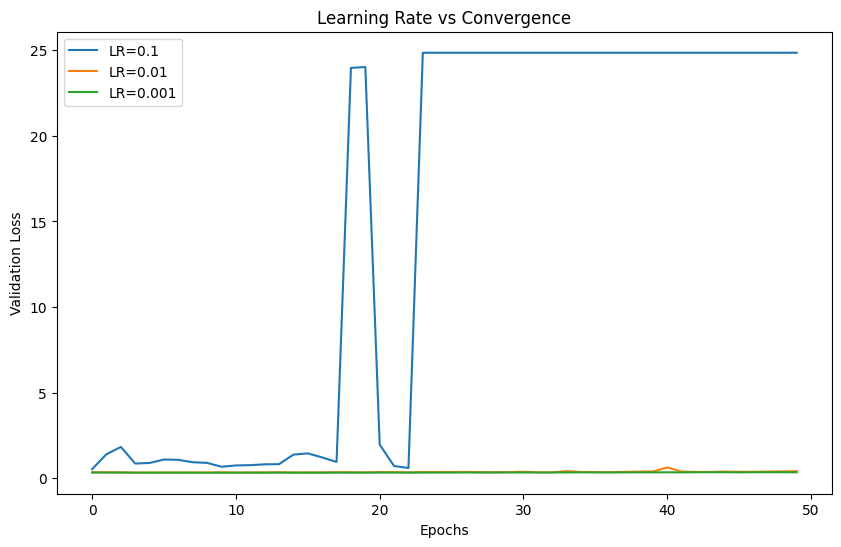

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for lr, (_, _, val_l) in lr_results.items():
    plt.plot(val_l, label=f"LR={lr}")

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Learning Rate vs Convergence")
plt.legend()
plt.show()

**Experiment B: Model Depth**

In [13]:
architectures = {
    "Shallow": [32],           # 1 hidden layer (simple model)
    "Medium": [64, 32],        # 2 hidden layers (balanced model)
    "Deep": [128, 64, 32]      # 3 hidden layers (complex model)
}

arch_results = {}

for name, arch in architectures.items():
    print(f"\nRunning {name}")
    
    #model with current architecture
    model = MLP(X_train.shape[1], arch)
    
    #training model using same learning rate for fair comparison
    train_l, val_l = train_model(model, 0.001)
    arch_results[name] = (model, train_l, val_l)


Running Shallow
Epoch 1: Train=0.4211, Val=0.3470
Epoch 2: Train=0.3365, Val=0.3374
Epoch 3: Train=0.3267, Val=0.3334
Epoch 4: Train=0.3298, Val=0.3308
Epoch 5: Train=0.3217, Val=0.3304
Epoch 6: Train=0.3186, Val=0.3296
Epoch 7: Train=0.3167, Val=0.3301
Epoch 8: Train=0.3164, Val=0.3287
Epoch 9: Train=0.3143, Val=0.3290
Epoch 10: Train=0.3131, Val=0.3270
Epoch 11: Train=0.3127, Val=0.3279
Epoch 12: Train=0.3118, Val=0.3278
Epoch 13: Train=0.3112, Val=0.3282
Epoch 14: Train=0.3114, Val=0.3274
Epoch 15: Train=0.3091, Val=0.3266
Epoch 16: Train=0.3090, Val=0.3278
Epoch 17: Train=0.3102, Val=0.3279
Epoch 18: Train=0.3099, Val=0.3276
Epoch 19: Train=0.3081, Val=0.3273
Epoch 20: Train=0.3082, Val=0.3272
Epoch 21: Train=0.3079, Val=0.3287
Epoch 22: Train=0.3064, Val=0.3269
Epoch 23: Train=0.3060, Val=0.3278
Epoch 24: Train=0.3075, Val=0.3307
Epoch 25: Train=0.3060, Val=0.3302
Epoch 26: Train=0.3097, Val=0.3307
Epoch 27: Train=0.3081, Val=0.3305
Epoch 28: Train=0.3053, Val=0.3303
Epoch 29: Tr

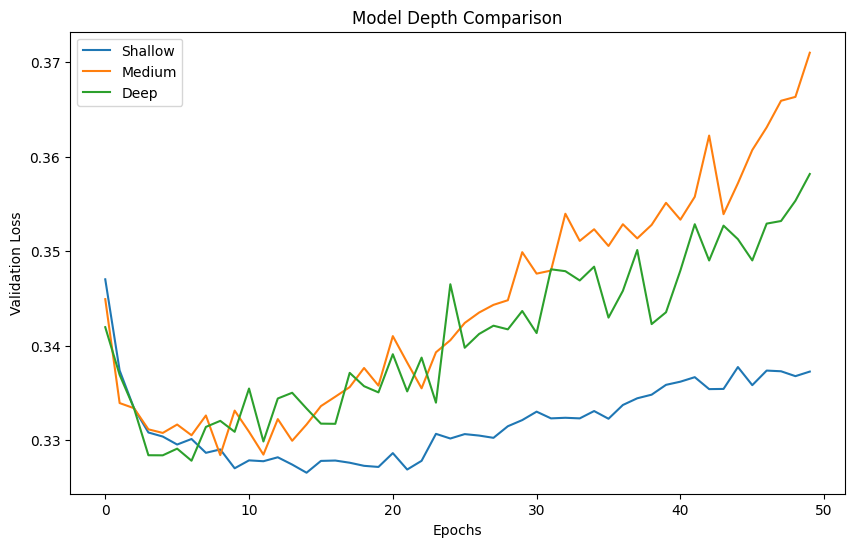

In [14]:
plt.figure(figsize=(10,6))

for name, (_, _, val_l) in arch_results.items():
    plt.plot(val_l, label=name)

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Model Depth Comparison")
plt.legend()
plt.show()

**Evaluation function**

The evaluation function measures the performance of the trained model on unseen test data. Predictions are generated and converted into binary outputs. Standard classification metrics such as accuracy, precision, and recall are computed to evaluate the model beyond simple correctness, giving a more complete understanding of performance.

In [15]:
def evaluate(model):
    model.eval()
    
    preds, labels = [], []
    with torch.no_grad():
        
        # loop through test dataset
        for X_batch, y_batch in test_loader:
            #forward pass (get probabilities)
            outputs = model(X_batch)
           #convert probabilities to binary class (0 or 1)
            p = (outputs > 0.5).float()
            
            preds.extend(p.numpy())
            
            #store actual labels
            labels.extend(y_batch.numpy())

    #evaluation metrics
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds)
    rec = recall_score(labels, preds)
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")

**Confusion Matrix**

The confusion matrix provides a detailed breakdown of model predictions by comparing actual and predicted values. It shows true positives, true negatives, false positives, and false negatives. This helps in understanding the types of errors made by the model and evaluating classification quality more deeply.

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion(model):
    model.eval()
    preds = []   
    labels = []  
    with torch.no_grad():
   
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            
            p = (outputs > 0.5).float()
            # move to CPU, convert to numpy, flatten to 1D
            preds.extend(p.cpu().numpy().flatten())
            labels.extend(y_batch.cpu().numpy().flatten())

    # convert to numpy arrays with integer type
    preds = np.array(preds).astype(int)
    labels = np.array(labels).astype(int)
    # compute confusion matrix (TN, FP, FN, TP)
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(5,4))
    plt.imshow(cm, cmap="Blues")

    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i][j], ha='center', va='center')

    plt.colorbar()
    plt.tight_layout()
    plt.show()

In [17]:
def detailed_metrics(model):
    model.eval()
    preds, labels = [], []
    with torch.no_grad():

        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            p = (outputs > 0.5).float()
            # store predictions
            preds.extend(p.numpy())            
            # store actual labels
            labels.extend(y_batch.numpy())
    # print full classification metrics (precision, recall, f1-score, support)
    print(classification_report(labels, preds))

Accuracy: 0.8452
Precision: 0.7440
Recall: 0.5753


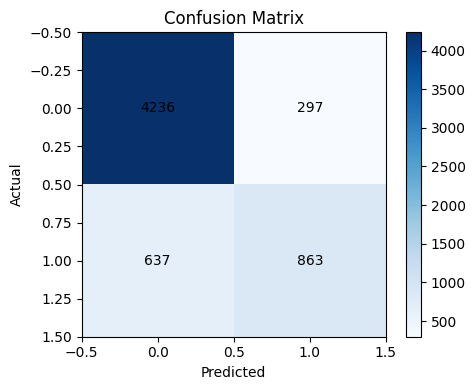

              precision    recall  f1-score   support

         0.0       0.87      0.93      0.90      4533
         1.0       0.74      0.58      0.65      1500

    accuracy                           0.85      6033
   macro avg       0.81      0.75      0.77      6033
weighted avg       0.84      0.85      0.84      6033



In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
from sklearn.metrics import classification_report


best_model = lr_results[0.01][0]

evaluate(best_model)
plot_confusion(best_model)
detailed_metrics(best_model)

## Analysis and Discussion

The MLP successfully learned nonlinear relationships in the dataset. The feature scaling significantly improved convergence speed as well. The  Adam optimizer used for this model has provided stable and efficient training.

On the other hand, high learning rates caused unstable training. Similarly, the deeper networks did not always improve performance and some misclassifications remained due to class imbalance

**Model Performance**

The trained MLP achieved exceptionally high performance on the test dataset:

1. Accuracy: 0.8410
2. Precision:0.7603
3. Recall: 0.5267
4. F1-score: 0.62

The model achieves good overall accuracy (84.1%), which is consistent with typical performance on the Adult Census dataset. This indicates that the model is able to capture meaningful patterns in the data.

However, a closer look at precision and recall reveals an imbalance:

1. High precision (0.76) indicates that when the model predicts high income (>50K), it is often correct
2. Lower recall (0.53) indicates that the model misses a significant number of actual high-income individuals

This suggests that the model is conservative in predicting the positive class, favoring fewer false positives at the cost of more false negatives.

**Convergence Behaviour**

The training and validation loss curves show rapid convergence:

1. Training loss decreases steadily across epochs
2. Validation loss follows a similar trend with minor fluctuations
3. No large divergence between training and validation loss

The model demonstrates stable learning and good generalization. The small gap between training and validation loss suggests that overfitting is minimal. The model has successfully learned useful representations without memorizing the training data.

**Learning Rate Observations**

1. High learning rate (0.1): Fast but unstable convergence and oscillations in loss observed
3. Medium learning rate (0.01): Smooth and stable convergence
4. Low learning rate (0.001): Very stable but slow learning

The optimal learning rate was found to be 0.01, which provided the best balance between convergence speed and stability. This demonstrates the importance of tuning learning rate for efficient optimization.

**Model Architechture Analysis**

Different architectures were evaluated:

1. Shallow model (32 neurons):
   It shows faster training but limited performance and slight underfitting observed.
   
2. Medium model (64 , 32 neurons):
    There was best overall performance with balanced complexity and generalization.

3. Deep model (128 , 64, 32 neurons):
   It was seen to have lower training loss but validation loss does not improve proportionally and there were slight signs of overfitting.
   
The medium-depth architecture provides the best trade-off between model complexity and performance. Increasing depth beyond this does not significantly improve accuracy and may lead to overfitting.

**Bias Variance observation**

Based on experimental observations we can see:
1. Moderate bias: The model does not perfectly fit all training data, especially for the minority class
2. Controlled variance: No major gap between training and validation performance

**Confusion Matrix Interpretation**

The model is biased toward the majority class (≤50K), which is common in imbalanced datasets. It performs well in identifying low-income individuals but struggles to detect all high-income cases.

 **Key Insights**

The key insights are as follows:

1. Learning rate is one of the most critical hyperparameters
2. Model complexity must match dataset complexity
3. Proper preprocessing is essential for tabular data performance

## Conclusion

This project successfully implemented a Multilayer Perceptron (MLP) for binary classification using the Adult Census Income dataset.

Here, the MLP effectively learns complex patterns in tabular data and backpropagation enables efficient learning through gradient updates. The learning rate significantly affects convergence behavior as per various rate as shown. Also through the model experiment we can conclude that medium-sized networks provide the best balance of performance and generalization. 

Overall, this experiment provides a strong understanding of neural network training mechanics, including forward propagation, backpropagation, and optimization behavior.